# Model Comparison: Finding the Best Sleep Disorder Classifier

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

## Load Saved Models

In [2]:
# Load all three pre-trained models
log_reg = joblib.load('logistic_regression_model.pkl')
dt = joblib.load('decision_tree_model.pkl')
rf = joblib.load('random_forest_model.pkl')

print("✓ Logistic Regression model loaded")
print("✓ Decision Tree model loaded")
print("✓ Random Forest model loaded")

✓ Logistic Regression model loaded
✓ Decision Tree model loaded
✓ Random Forest model loaded


## Load and Prepare Dataset

In [3]:
# Load the processed data
df = pd.read_csv('processed_sleep_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget variable distribution:")
print(df['Sleep Disorder'].value_counts())

Dataset shape: (374, 13)

Target variable distribution:
Sleep Disorder
1    219
2     78
0     77
Name: count, dtype: int64


## Split Data (Same as Training)

In [4]:
# Split into Features (X) and Target (y)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# Split with the same random_state to get identical train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

class_names = ['Insomnia', 'None', 'Sleep Apnea']
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (299, 12)
Testing data shape: (75, 12)


## Make Predictions with All Models

In [5]:
# Get predictions from all models
predictions = {
    'Logistic Regression': log_reg.predict(X_test),
    'Decision Tree': dt.predict(X_test),
    'Random Forest': rf.predict(X_test)
}

print("✓ Predictions completed for all models")

✓ Predictions completed for all models


## Evaluate Model Performance

In [6]:
# Calculate metrics for each model
results = []

for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

print("✓ Evaluation complete!")

✓ Evaluation complete!


## Compare Models Using Metrics

In [7]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.960000   0.961667 0.960000  0.960569
      Decision Tree  0.946667   0.957895 0.946667  0.947658
Logistic Regression  0.920000   0.922230 0.920000  0.920189


## Visualize Model Comparison

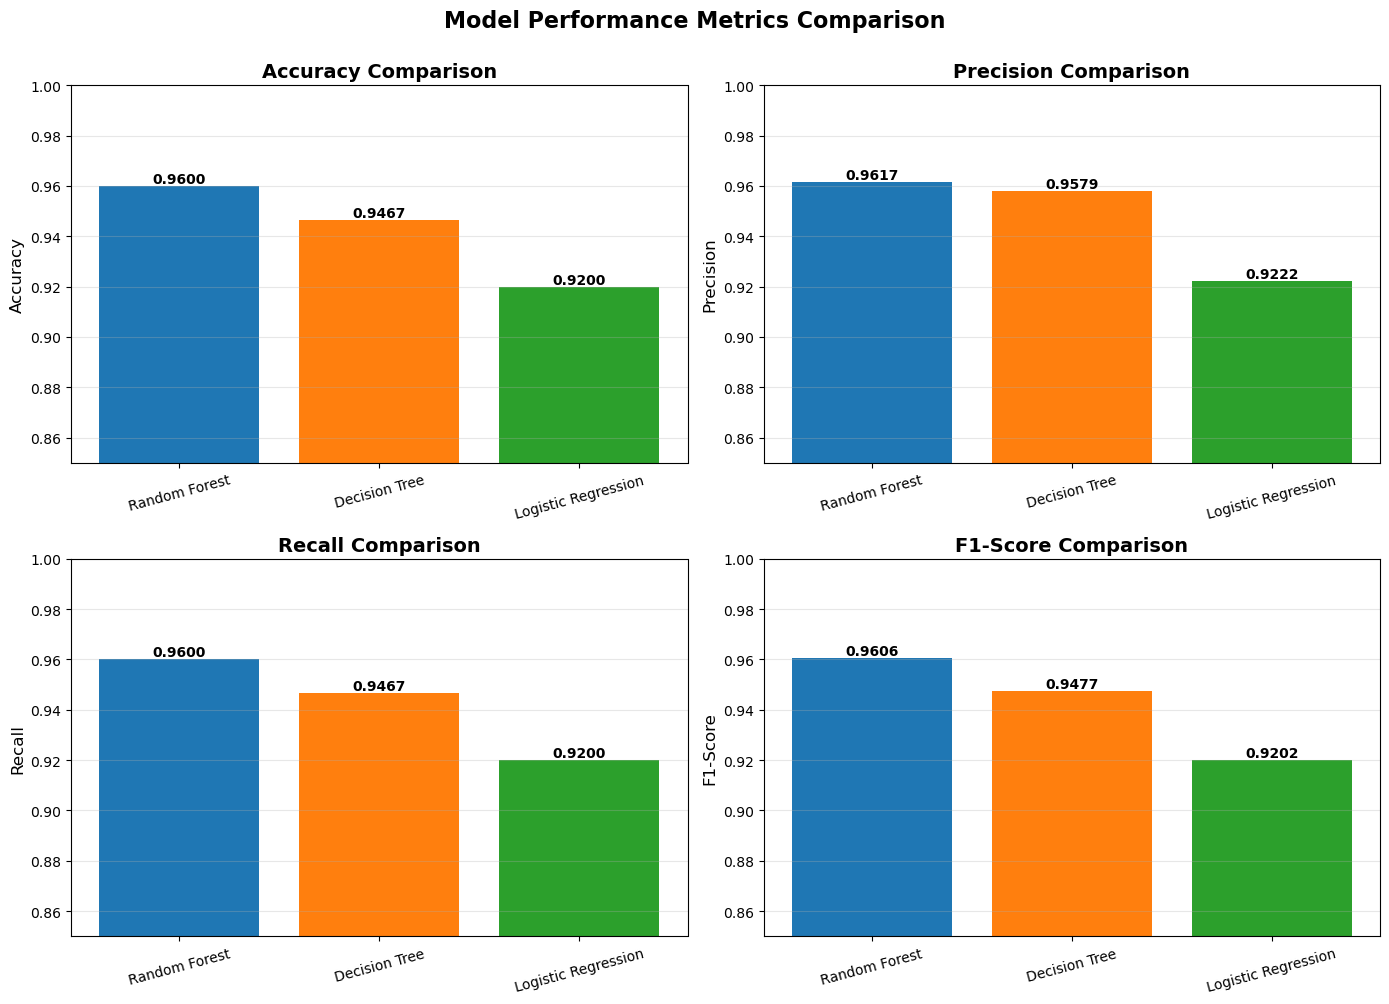

In [8]:
# Bar chart comparison of all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0.85, 1.0])
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Confusion Matrices Comparison

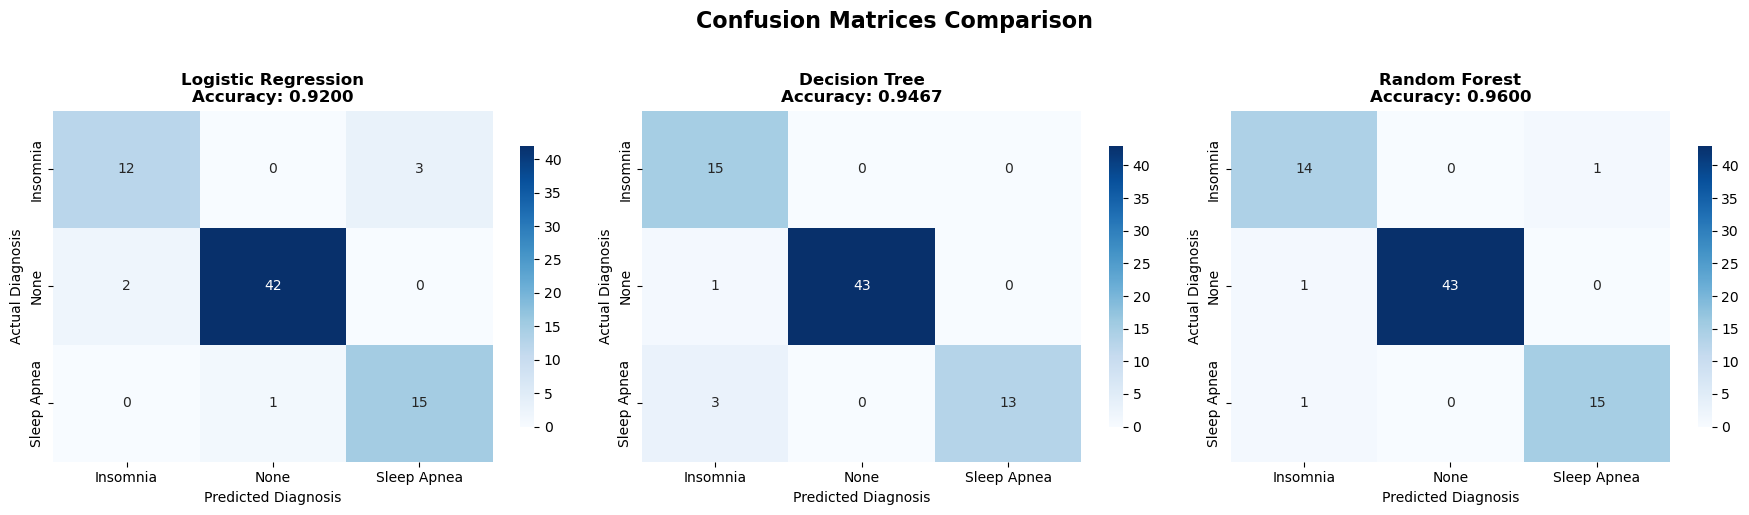

In [9]:
# Plot confusion matrices for all models side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Diagnosis', fontsize=10)
    axes[idx].set_ylabel('Actual Diagnosis', fontsize=10)

plt.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Per-Class Performance Analysis

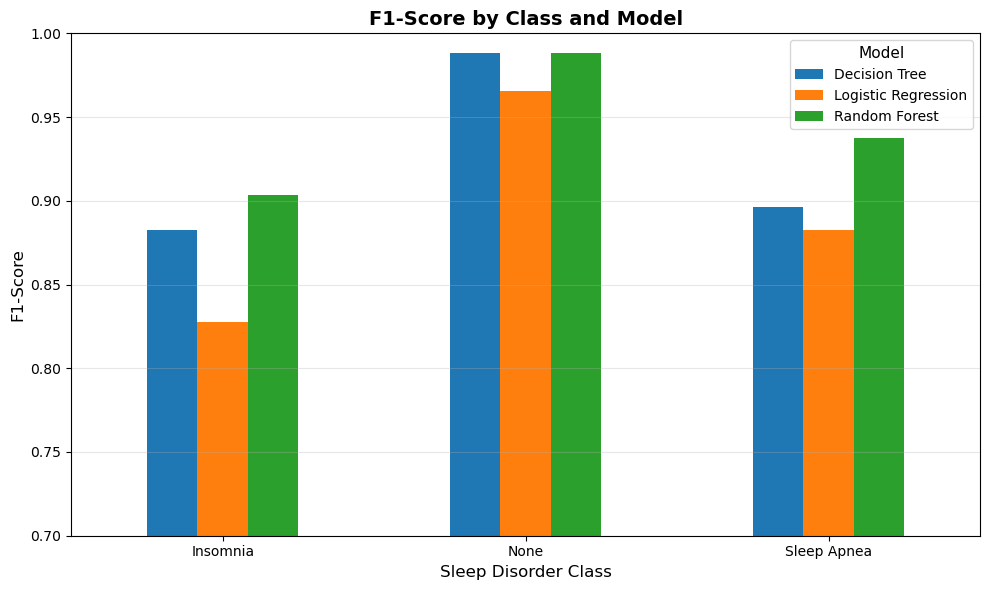


Per-Class Performance Details:
              Model       Class  Precision   Recall  F1-Score
Logistic Regression    Insomnia   0.857143 0.800000  0.827586
Logistic Regression        None   0.976744 0.954545  0.965517
Logistic Regression Sleep Apnea   0.833333 0.937500  0.882353
      Decision Tree    Insomnia   0.789474 1.000000  0.882353
      Decision Tree        None   1.000000 0.977273  0.988506
      Decision Tree Sleep Apnea   1.000000 0.812500  0.896552
      Random Forest    Insomnia   0.875000 0.933333  0.903226
      Random Forest        None   1.000000 0.977273  0.988506
      Random Forest Sleep Apnea   0.937500 0.937500  0.937500


In [10]:
# Compare performance per class
per_class_results = []

for model_name, y_pred in predictions.items():
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    for class_name in class_names:
        per_class_results.append({
            'Model': model_name,
            'Class': class_name,
            'Precision': report[class_name]['precision'],
            'Recall': report[class_name]['recall'],
            'F1-Score': report[class_name]['f1-score']
        })

per_class_df = pd.DataFrame(per_class_results)

# Plot per-class F1-scores
pivot_df = per_class_df.pivot(index='Class', columns='Model', values='F1-Score')
pivot_df.plot(kind='bar', figsize=(10, 6), rot=0, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('F1-Score by Class and Model', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Sleep Disorder Class', fontsize=12)
plt.legend(title='Model', title_fontsize=11, fontsize=10)
plt.ylim([0.7, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPer-Class Performance Details:")
print(per_class_df.to_string(index=False))

## Select the Best Model

In [11]:
# Determine the best model based on accuracy
best_model_row = results_df.iloc[0]
best_model_name = best_model_row['Model']
best_accuracy = best_model_row['Accuracy']

print("\n" + "="*70)
print("🏆 BEST MODEL SELECTION")
print("="*70)
print(f"\n   Model Name:  {best_model_name}")
print(f"   Accuracy:    {best_model_row['Accuracy']:.4f} ({best_model_row['Accuracy']*100:.2f}%)")
print(f"   Precision:   {best_model_row['Precision']:.4f}")
print(f"   Recall:      {best_model_row['Recall']:.4f}")
print(f"   F1-Score:    {best_model_row['F1-Score']:.4f}")
print("\n" + "="*70)
print(f"\n✓ The {best_model_name} model is recommended for sleep disorder classification.")
print("="*70)


🏆 BEST MODEL SELECTION

   Model Name:  Random Forest
   Accuracy:    0.9600 (96.00%)
   Precision:   0.9617
   Recall:      0.9600
   F1-Score:    0.9606


✓ The Random Forest model is recommended for sleep disorder classification.


## Summary

This notebook loads and compares three pre-trained machine learning models for sleep disorder classification:

### Models Evaluated:
1. **Logistic Regression**: A linear model that's interpretable and efficient for binary and multiclass classification
2. **Decision Tree**: A non-linear model that captures complex decision boundaries through tree-based rules
3. **Random Forest**: An ensemble of decision trees that provides improved stability and reduced overfitting

### Evaluation Metrics:
- **Accuracy**: Overall correctness of predictions
- **Precision**: Ability to avoid false positives
- **Recall**: Ability to identify all positive cases
- **F1-Score**: Harmonic mean of precision and recall

### Key Findings:
The comparison includes:
- Overall performance metrics across all models
- Confusion matrices showing prediction patterns for each model
- Per-class performance analysis for each sleep disorder category (Insomnia, None, Sleep Apnea)
- Best model selection based on comprehensive evaluation

The models were saved using joblib after training in their respective notebooks, allowing for efficient reuse and comparison without retraining.

### Workflow:
1. Train models in individual notebooks (Logistic_Regression.ipynb, Decision_Tree.ipynb, Random_Forest.ipynb)
2. Export trained models using joblib
3. Load and compare models in this notebook
4. Select the best performing model for deployment